# Advanced Deep Learning - Exercise 3 - Transformers

In this exercise, we will look at transformers for shape vision. Specifically, we will implement a vision transformer for image classification.


All parts you have to implement are marked with `YOUR CODE HERE` / `TODO`.


This exercise requires additional files. If you plan on using Colab, please upload the (extracted) folder to your drive and follow the steps below.


In [ ]:
from google.colab import drive

drive.mount("/content/drive")

The command below assumes that you uploaded the folder `ADL_Ex04` in the home of your Google Drive. If you uploaded it in a different folder/subfolder, you need to modify the path.


In [ ]:
%cd "/content/drive/MyDrive/ADL_Ex04"

In [2]:
! pip install wandb
! pip install lightning
! pip install seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 44.7 MB/s eta 0:00:00


To connect with wandb for logging, comment out the following line.
Don't forget to comment it out afterwards as you don't need to run this on repeated executions.


In [ ]:
# !timeout 5m wandb init

In [5]:
import lightning as L
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from lightning.pytorch.loggers import WandbLogger
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import v2

import wandb

## Image To Patches


In [6]:
def img_to_patch(img, patch_size, channel_size):
    """
    Converts an image into patches.

    Args:
        img (torch.Tensor or numpy.ndarray): The input image. If it is a tensor, it should have shape (B, C, H, W),
            where C is the number of channels, H is the height, and W is the width. If it is a numpy array,
            it should have shape (H, W, C).
        patch_size (int): The size of each patch.
        channel_size (int): The number of channels in the image.

    Returns:
        torch.Tensor: The flattened patches of shape (B, N, C*P*P), where B is the batch size, N is the number of patches,
        C is the number of channels, and P is the patch size.
    """
    P, C = patch_size, channel_size
    # check if image is tensor or numpy array
    if isinstance(img, torch.Tensor):
        img = img
    else:
        img = torch.tensor(img).permute(2, 0, 1).unsqueeze(0)

    ### YOUR CODE HERE
    # split image into patches
    patches = F.pixel_unshuffle(img, P)  # TODO

    # flatten patches
    flatten_patches = patches.flatten(2).transpose(1, 2)  # TODO
    ### END YOUR CODE

    return flatten_patches

In [ ]:
from unit_tests import test_img_to_patch

test_img_to_patch(img_to_patch)

Image shape:  (128, 128, 3)
Number of patches: 64 with resolution (16, 16)
Flattened patches shape:  torch.Size([1, 64, 768])


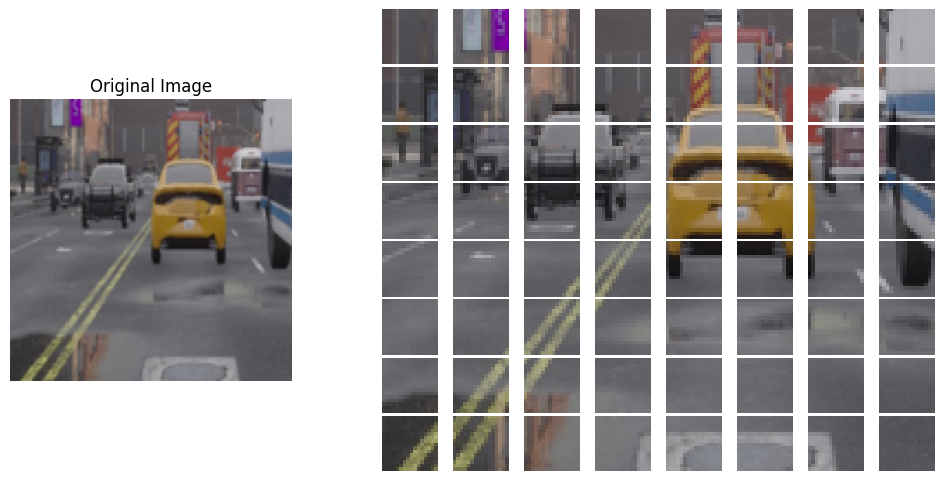

In [ ]:
from unit_tests import display_img_and_patches

display_img_and_patches(img_to_patch)

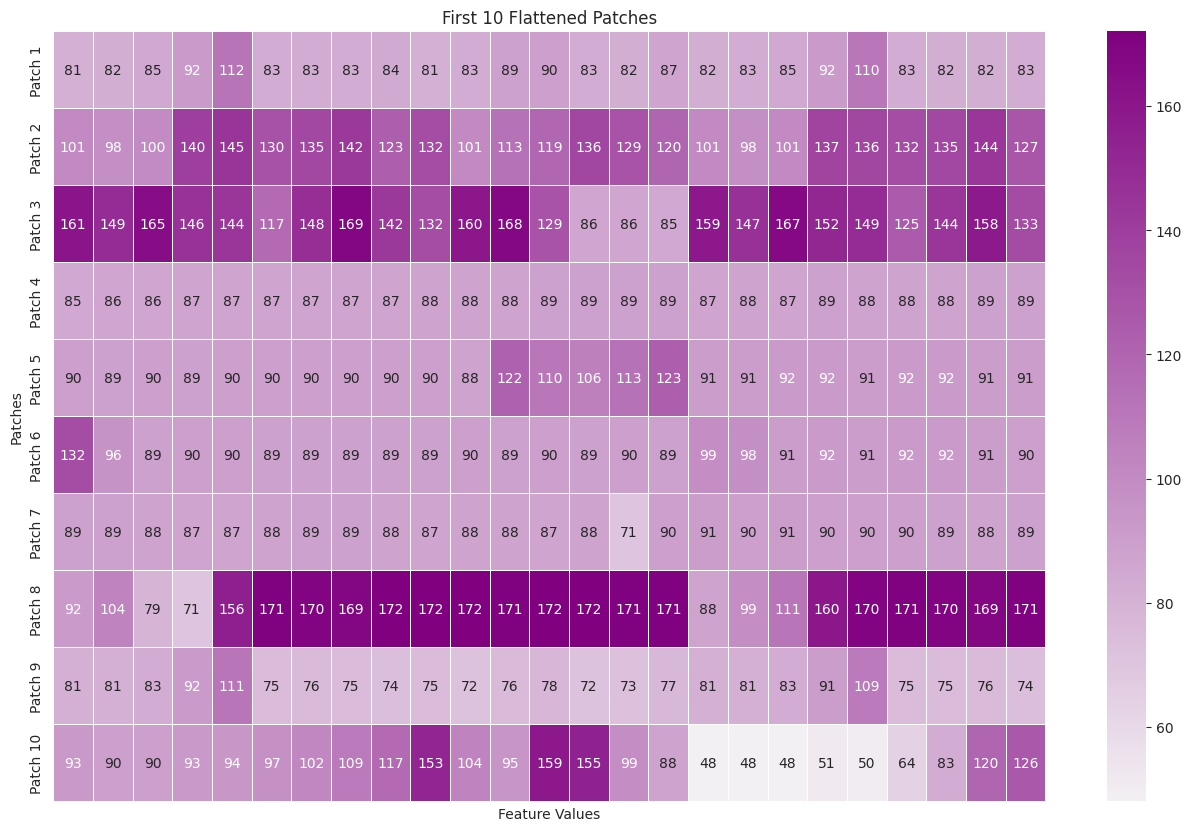

In [9]:
# Display flattened patches
display_img_and_patches(img_to_patch, heatmap=True)

## Embedding Patches


> The Transformer maintains a constant latent vector size, D, across all its layers. To achieve this, we map the flatten patches to D dimensions using a trainable linear projection. We refer to the output of this projection as the 'patch embeddings'.


In [ ]:
class PatchEmbedding(nn.Module):
    def __init__(self, patch_size, num_channels, embedding_dim):
        """
        Initializes the PatchEmbedding module.

        Args:
        - patch_size (int): Size of each patch (height and width).
        - num_channels (int): Number of channels in each patch.
        - embedding_dim (int): Dimensionality of the output patch embeddings.
        """
        super().__init__()

        self.patch_size = patch_size
        self.num_channels = num_channels
        self.embedding_dim = embedding_dim

        ### YOUR CODE HERE
        # Create a learnable embedding matrix
        self.embedding_matrix = nn.Linear(
            (patch_size**2) * num_channels, embedding_dim
        )  # TODO
        ### END YOUR CODE

    def forward(self, flatten_patches):
        """
        Forward pass of the PatchEmbedding module.

        Args:
        - flatten_patches (torch.Tensor): Tensor of shape (B, N, C*P*P) where B is batch size,
                                          N is number of patches, P is the patch size, and C is the number of channels.

        Returns:
        - torch.Tensor: Patch embeddings of shape (B, N, embedding_dim).
        """

        ### YOUR CODE HERE
        patch_embeddings = self.embedding_matrix(flatten_patches)  # TODO
        ### END YOUR CODE
        return patch_embeddings

In [ ]:
# unit test on patch embeddings
from unit_tests import test_patch_embeddings

test_patch_embeddings(PatchEmbedding)

Output shape is correct: torch.Size([10, 20, 768])


## Class Token


To perform classification, we adopt the standard approach of adding an extra learnable 'classification token' to the sequence.


In [ ]:
class ClassToken(nn.Module):
    def __init__(self, embedding_dim):
        super().__init__()
        ### YOUR CODE HERE
        self.class_token = nn.Parameter(torch.randn(1, 1, embedding_dim))
        ### END YOUR CODE

    def forward(self, x):
        ### YOUR CODE HERE
        B = x.shape[0]
        cls_token = self.class_token.expand(B, -1, -1)

        # prepend cls token
        x = torch.cat([cls_token, x], dim=1)
        ### END YOUR CODE
        return x

In [ ]:
# unit test on class token
from unit_tests import test_class_token

test_class_token(ClassToken)

ClassToken Test Passed: Output shape is correct.


## Position Encoding


> Position encoding enables the model to understand the original spatial arrangement of patches within an image. ViT uses learnable position encoding.


In [33]:
class PositionalEncoding(nn.Module):
    def __init__(self, num_patches, embedding_dim):
        """
        Initialize the PositionalEncoding module.

        Args:
        - num_patches (int): Number of patches per image, which defines the length of the sequence.
        - embedding_dim (int): Dimensionality of the embedding space.

        This module uses a learnable positional encoding.
        """
        super().__init__()

        ### YOUR CODE HERE
        # Create a learnable embedding of shape (num_patches, embedding_dim)
        self.positional_encoding = nn.Parameter(
            torch.empty(1, num_patches, embedding_dim)
        )
        ### END YOUR CODE
        self.reset_parameters()

    def reset_parameters(self):
        """
        Initialize the positional encoding parameters with a uniform distribution for better convergence.
        """
        ### YOUR CODE HERE
        # Initialize the positional encoding parameters with a uniform distribution
        nn.init.uniform_(self.positional_encoding, -0.02, 0.02)
        ### END YOUR CODE

    def forward(self, x):
        """
        Add positional encoding to the input tensor.

        Args:
        - x (torch.Tensor): The input feature tensor of shape (batch_size, num_patches, embedding_dim).

        Returns:
        - torch.Tensor: Output feature tensor with positional encoding added to it.
        """
        ### YOUR CODE HERE
        x = x + self.positional_encoding
        ### END YOUR CODE
        return x

In [ ]:
# position encoded embeddings
from unit_tests import test_positional_encoding

test_positional_encoding(PositionalEncoding)

Shape of encoded features: torch.Size([10, 100, 768])
Positional Encoding Test Passed: Output shape is correct.


## Multi-Head Attention


In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, embedding_dim, num_heads):
        """
        Initializes the MultiHeadAttention module.

        Args:
        - embedding_dim (int): The size of the input feature dimension.
        - num_heads (int): Number of attention heads.
        """
        super().__init__()

        self.num_heads = num_heads
        self.embedding_dim = embedding_dim

        # Ensure the embedding dimension is divisible by the number of heads
        assert embedding_dim % num_heads == 0, (
            "Embedding dimension must be divisible by num_heads"
        )

        self.depth = embedding_dim // num_heads

        # These are fully connected layers for transforming input to queries, keys, and values.
        self.wq = nn.Linear(embedding_dim, embedding_dim, bias=False)
        self.wk = nn.Linear(embedding_dim, embedding_dim, bias=False)
        self.wv = nn.Linear(embedding_dim, embedding_dim, bias=False)

        # This fully connected layer is for projecting the concatenated outputs.
        self.dense = nn.Linear(embedding_dim, embedding_dim)

    def split_heads(self, x, batch_size):
        """
        Split the last dimension into (num_heads, depth).
        Transpose the result such that the shape is (batch_size, num_heads, seq_length, depth)
        """
        x = x.view(batch_size, -1, self.num_heads, self.depth)
        return x.permute(0, 2, 1, 3)

    def forward(self, x):
        batch_size = x.shape[0]

        ### YOUR CODE HERE
        # Linear transformations
        query = self.wq(x)  # TODO
        key = self.wk(x)  # TODO
        value = self.wv(x)  # TODO

        # Split into heads
        query = self.split_heads(query, batch_size)
        key = self.split_heads(key, batch_size)
        value = self.split_heads(value, batch_size)

        # Scaled dot-product attention
        matmul_qk = torch.matmul(
            query, key.transpose(-2, -1)
        )  # (batch_size, num_heads, seq_len, seq_len)  # TODO

        # Scale the dot products
        dk = torch.sqrt(torch.tensor(self.depth, dtype=torch.int8))  # TODO
        scaled_attention_logits = matmul_qk / dk  # TODO
        # Apply the softmax normalized on the last axis (seq_len_k) so that the
        # scores add up to 1.
        attention_weights = F.softmax(scaled_attention_logits, dim=-1)  # TODO

        # Multiply by value
        output = torch.matmul(
            attention_weights, value
        )  # (batch_size, num_heads, seq_len, depth)  # TODO
        ### END YOUR CODE

        # Concatenate heads
        output = output.permute(0, 2, 1, 3).contiguous()
        output = output.view(
            batch_size, -1, self.embedding_dim
        )  # (batch_size, seq_len, embedding_dim)

        # Pass through a final dense layer
        output = self.dense(output)

        return output

In [ ]:
# unit test on multi-head self-attention
from unit_tests import test_multi_head_self_attention

test_multi_head_self_attention(MultiHeadAttention)

MultiHeadSelfAttention Test Passed: Output shape is correct.


## Multi-Layer Perceptron


> The MLP contains two layers with a GELU non-linearity.


In [25]:
class MultiLayerPerceptron(nn.Module):
    def __init__(self, embedding_dim=768, hidden_dim=3072):
        super().__init__()

        self.mlp = nn.Sequential(
            nn.Linear(embedding_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, embedding_dim),
        )

    def forward(self, x):
        # pass through multi-layer perceptron
        return self.mlp(x)

In [ ]:
# unit test on multi-layer perceptron
from unit_tests import test_mlp

test_mlp(MultiLayerPerceptron)

MLP Test Passed: Output shape is correct.


## Transformer Encoder Block


> The Transformer encoder consists of alternating layers of multiheaded self-attention (MSA) and MLP blocks. Layernorm (LN) is applied before every block, and residual connections after every block.


In [ ]:
class TransformerEncoder(nn.Module):
    def __init__(
        self, embedding_dim=768, num_heads=12, hidden_dim=3072, dropout_prob=0.1
    ):
        super().__init__()

        ### YOUR CODE HERE
        # Multi-Head Self Attention
        self.MSA = MultiHeadAttention(embedding_dim, num_heads)  # TODO
        # Feed Forward Network (MLP in this case)
        self.MLP = MultiLayerPerceptron(embedding_dim, hidden_dim)  # TODO

        # Layer Normalization before the Self-Attention and the Feed Forward Network
        self.layer_norm1 = nn.LayerNorm(embedding_dim)  # TODO
        self.layer_norm2 = nn.LayerNorm(embedding_dim)  # TODO

        # Optional: Dropout can be added after self-attention and MLP for regularization
        self.dropout1 = nn.Dropout(dropout_prob)  # TODO
        self.dropout2 = nn.Dropout(dropout_prob)  # TODO
        ### END YOUR CODE

    def forward(self, x):
        ### YOUR CODE HERE
        # Layer Normalization followed by Multi-Head Self-Attention and dropout
        norm_x = self.layer_norm1(x)
        attention_output = self.MSA(norm_x)
        attention_output = self.dropout1(attention_output)

        # Add and Norm (Residual Connection)
        x = x + attention_output

        # Layer Normalization followed by MLP and dropout
        norm_x = self.layer_norm2(x)
        mlp_output = self.MLP(norm_x)
        mlp_output = self.dropout2(mlp_output)

        # Add and Norm (Residual Connection)
        output = x + mlp_output
        ### END YOUR CODE

        return output

In [ ]:
# unit test on transformer encoder
from unit_tests import test_transformer_encoder

test_transformer_encoder(TransformerEncoder)

TransformerEncoder Test Passed: Output shape is correct.


## Classification Head


> In order to stay as close as possible to the original Transformer model, we made use of an additional [class] token, which is taken as image representation. The output of this token is then transformed into a class prediction via a small multi-layer perceptron (MLP).


In [29]:
class ClassificationHead(nn.Module):
    def __init__(self, embedding_dim=768, num_classes=10):
        super().__init__()

        self.num_classes = num_classes
        self.cls_head = nn.Sequential(
            nn.Linear(embedding_dim, num_classes),
        )

    def forward(self, x):
        x = self.cls_head(x)
        return x

In [ ]:
# unit test on classification head
from unit_tests import test_classification_head

test_classification_head(ClassificationHead)

ClassificationHead Test Passed: Output shape is correct.


## Vision Transformer


In [ ]:
class VisionTransformer(nn.Module):
    def __init__(
        self,
        patch_size=16,
        image_size=224,
        num_channels=3,
        num_layers=12,
        embedding_dim=768,
        num_heads=12,
        hidden_dim=3072,
        dropout_prob=0.1,
        num_classes=10,
    ):
        super().__init__()

        self.patch_size = patch_size
        self.num_channels = num_channels
        self.num_layers = num_layers
        self.embedding_dim = embedding_dim
        self.num_heads = num_heads
        self.hidden_dim = hidden_dim
        self.dropout_prob = dropout_prob
        self.num_classes = num_classes

        ### YOUR CODE HERE
        self.num_patches = (image_size // patch_size) ** 2  # TODO
        self.patch_embedding = PatchEmbedding(
            patch_size, num_channels, embedding_dim
        )  # TODO
        self.pos_embedding = PositionalEncoding(self.num_patches, embedding_dim)  # TODO
        self.class_token = ClassToken(embedding_dim)  # TODO

        self.transformer_encoders = nn.ModuleList(
            [
                TransformerEncoder(
                    embedding_dim=embedding_dim,
                    num_heads=num_heads,
                    hidden_dim=hidden_dim,
                    dropout_prob=dropout_prob,
                )
                for _ in range(num_layers)
            ]
        )
        ### END YOUR CODE

        self.mlp_head = ClassificationHead(embedding_dim, num_classes)

    def forward(self, x):
        P, C = self.patch_size, self.num_channels

        ### YOUR CODE HERE
        x = img_to_patch(x, P, C)
        x = self.patch_embedding(x)
        x = self.pos_embedding(x)
        x = self.class_token(x)

        for encoder in self.transformer_encoders:
            x = encoder(x)
        ### END YOUR CODE

        # Extract the output for the class token
        x = x[:, 0]

        return self.mlp_head(x)

In [ ]:
# unit test on vision transformer
from unit_tests import test_vision_transformer

test_vision_transformer(VisionTransformer)

VisionTransformer Test Passed: Output shape is correct.


## Training Vision Transformer


In [41]:
args = {}

# Give your experiment a meaningful name, and change it for every new experiment
args["dataset_path"] = "/tmp/cifar10"
args["experiment_name"] = "Vit_Training"
args["project_name"] = "adl26_exercise_03"

# architecture
args["patch_size"] = 16
args["image_size"] = 32
args["num_channels"] = 3
args["num_layers"] = 4
args["embedding_dim"] = 64
args["num_heads"] = 4
args["hidden_dim"] = 128
args["dropout_prob"] = 0.1
args["num_classes"] = 10

# training and testing args
args["momentum"] = 0.9
args["lr"] = 0.01
args["epochs"] = 20
args["batch_size"] = 256
args["test_batch_size"] = 256
args["log_interval"] = 1

# random seed for reproducibility
args["seed"] = 42


torch.manual_seed(args["seed"])

In [ ]:
class CIFAR10DataModule(L.LightningDataModule):
    def __init__(
        self,
        data_dir,
        batch_size,
        test_batch_size,
        train_transforms=None,
        val_transforms=None,
        **kwargs,
    ):
        super().__init__()

        self.data_dir = data_dir
        self.batch_size = batch_size
        self.test_batch_size = test_batch_size
        self.kwargs = kwargs

        default_transforms = v2.Compose(
            [
                v2.ToTensor(),
                v2.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
            ]
        )

        if train_transforms is not None:
            self.transforms_train = train_transforms
        else:
            self.transforms_train = default_transforms

        if val_transforms is not None:
            self.transforms_val = val_transforms
        else:
            self.transforms_val = default_transforms

    def prepare_data(self):
        # Called only once and on 1 GPU
        datasets.CIFAR10(self.data_dir, train=True, download=True)
        datasets.CIFAR10(self.data_dir, train=False, download=True)

    def setup(self, stage=None):
        self.train_dataset = datasets.CIFAR10(
            self.data_dir, train=True, transform=self.transforms_train
        )
        self.test_dataset = datasets.CIFAR10(
            self.data_dir, train=False, transform=self.transforms_val
        )

    def train_dataloader(self):
        return DataLoader(
            self.train_dataset, batch_size=self.batch_size, shuffle=True, **self.kwargs
        )

    def val_dataloader(self):  # We use test set as validation
        return DataLoader(
            self.test_dataset,
            batch_size=self.test_batch_size,
            shuffle=False,
            **self.kwargs,
        )

    def get_classes(self):
        return self.train_dataset.classes

    def configure_optimizers(self):
        optimizer = optim.SGD(
            self.model.parameters(),
            lr=self.config["lr"],
            momentum=self.config["momentum"],
        )
        scheduler = optim.lr_scheduler.MultiStepLR(
            optimizer, milestones=[1000], gamma=0.1
        )
        return [optimizer], [scheduler]

    def visualize_data(self, num_samples=6):
        loader = self.train_dataloader()
        images, labels = next(iter(loader))

        classes = self.get_classes()

        def unnormalize(img):
            return img * 0.5 + 0.5

        num_cols = min(num_samples, 3)
        num_rows = (num_samples + num_cols - 1) // num_cols

        fig, axs = plt.subplots(
            num_rows, num_cols, figsize=(num_cols * 3, num_rows * 3)
        )
        axs = axs.flatten()

        for idx in range(num_samples):
            img = unnormalize(images[idx]).permute(1, 2, 0).numpy()
            lbl = labels[idx].item()

            axs[idx].imshow(img)
            axs[idx].set_title(f"{classes[lbl]}")
            axs[idx].axis("off")

        # Hide any extra subplots
        for i in range(num_samples, len(axs)):
            axs[i].axis("off")

        plt.tight_layout()
        plt.show()

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 170M/170M [00:03<00:00, 53.8MB/s]


['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


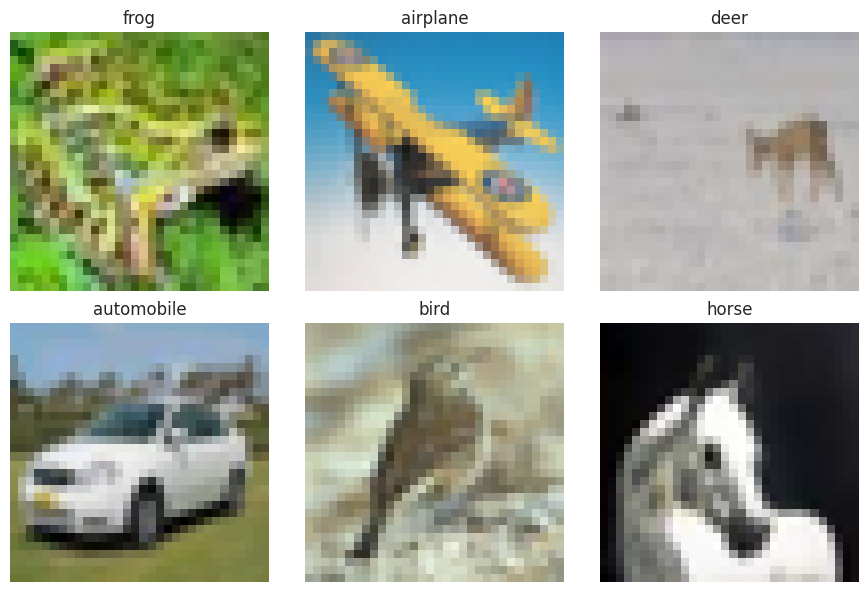

In [ ]:
data_module = CIFAR10DataModule(
    data_dir=args["dataset_path"],
    batch_size=args["batch_size"],
    test_batch_size=args["test_batch_size"],
    num_workers=4,
    pin_memory=True,
)

data_module.prepare_data()
data_module.setup()

print(data_module.get_classes())
data_module.visualize_data(num_samples=6)

In [44]:
class LitViT(L.LightningModule):
    def __init__(self, model, args, classes):
        super().__init__()

        self.model = model
        self.args = args
        self.classes = classes

        self.lr = args["lr"]
        self.momentum = args["momentum"]
        self.criterion = nn.CrossEntropyLoss()

        self.save_hyperparameters(args, ignore=["model", "classes"])

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        data, target = batch

        output = self(data)

        loss = self.criterion(output, target)
        acc = (output.argmax(dim=1) == target).float().mean()

        self.log("train_loss", loss, on_step=True, on_epoch=True, prog_bar=True)
        self.log("train_acc", acc, on_step=True, on_epoch=True, prog_bar=True)

        return loss

    def validation_step(self, batch, batch_idx):
        data, target = batch

        output = self(data)

        loss = self.criterion(output, target)
        acc = (output.argmax(dim=1) == target).float().mean()

        self.log("val_loss", loss, on_epoch=True, prog_bar=True)
        self.log("val_acc", acc, on_epoch=True, prog_bar=True)

    def configure_optimizers(self):
        optimizer = torch.optim.SGD(
            self.model.parameters(),
            lr=self.lr,
            momentum=self.momentum,
        )

        scheduler = torch.optim.lr_scheduler.MultiStepLR(
            optimizer,
            milestones=[1000],
            gamma=0.1,
        )

        return [optimizer], [scheduler]

    def visualize_predictions(self, test_loader, device, num_samples=6):
        fig = plt.figure()
        examples = enumerate(test_loader)

        batch_idx, (example_data, example_targets) = next(examples)
        self.eval()
        with torch.no_grad():
            output = self(example_data)
        num_cols = 3
        num_rows = (num_samples + num_cols - 1) // num_cols
        for i in range(num_samples):
            plt.subplot(num_cols, num_rows, i + 1)
            plt.tight_layout()
            img = example_data[i].permute(1, 2, 0) / 2 + 0.5
            plt.imshow(img, interpolation="none")
            plt.title(
                "Prediction: {}".format(
                    self.classes[output.cpu().data.max(1, keepdim=True)[1][i].item()]
                )
            )
            plt.xticks([])
            plt.yticks([])
        plt.show()

In [45]:
model = VisionTransformer(
    patch_size=args["patch_size"],
    image_size=args["image_size"],
    num_channels=args["num_channels"],
    num_layers=args["num_layers"],
    embedding_dim=args["embedding_dim"],
    num_heads=args["num_heads"],
    hidden_dim=args["hidden_dim"],
    dropout_prob=args["dropout_prob"],
    num_classes=args["num_classes"],
)

In [46]:
lit_model = LitViT(model, args, classes=data_module.get_classes())

wandb_logger = WandbLogger(project=args["project_name"], name=args["experiment_name"])
trainer = L.Trainer(
    max_epochs=args["epochs"],
    logger=wandb_logger,
    accelerator="auto",
    devices="auto",
    log_every_n_steps=args["log_interval"],
)

trainer.fit(lit_model, datamodule=data_module)

wandb.finish()

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

 3


wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin
wandb: WARNING `resume` will be ignored since W&B syncing is set to `offline`. Starting a new run with run id gtvn2drh.


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ VisionTransformer │  183 K │ train │     0 │
│ 1 │ criterion │ CrossEntropyLoss  │      0 │ train │     0 │
└───┴───────────┴───────────────────┴────────┴───────┴───────┘

...

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will 
create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller 
than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader 
running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will 
create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller 
than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader 
running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()

INFO: `Trainer.fit` stopped: `max_epochs=20` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.


epoch,▁▁▁▁▁▂▂▂▂▂▂▂▂▂▂▃▃▃▃▄▄▅▅▅▅▅▅▅▆▆▆▇▇▇▇▇▇███
train_acc_epoch,▁▃▄▄▅▅▅▆▆▆▆▇▇▇▇▇████
train_acc_step,▁▁▃▂▃▃▅▃▅▄▄▄▄▄▄▃▅▄▃▅▇▇▅▆▇▆▅▄▆▇▇▅▅▆▆▇█▇▆▆
train_loss_epoch,█▆▅▅▄▄▄▃▃▃▃▂▂▂▂▂▁▁▁▁
train_loss_step,█▇▆▆▅▆▅▆▆▅▅▄▄▅▄▄▃▃▃▃▃▃▃▄▂▄▃▃▂▃▃▂▃▂▃▂▁▁▂▁
trainer/global_step,▁▁▁▂▂▂▂▂▂▂▂▃▃▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▇▇▇▇▇█
val_acc,▁▃▄▅▅▆▆▆▇▇▇▇▇███████
val_loss,█▆▅▄▄▃▃▃▂▂▂▂▂▁▁▂▁▁▁▁
epoch,19
train_acc_epoch,0.60572
train_acc_step,0.4875


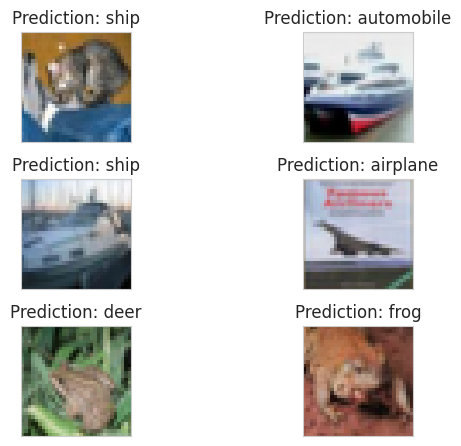

In [48]:
lit_model.visualize_predictions(data_module.val_dataloader(), "cuda")